#Word2Vec+SVM

##DATASET LOADING

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/gdrive/MyDrive/Dissertation Files/Sentiment_Mental_health_dataset.csv')


In [ ]:
df.head()

,statement,status
0,Anyone else have symptoms much improved after ...,Bipolar
1,"I basicaly do not exist, sure feels that way. ...",Suicidal
2,Finding a sense of self It's like one minute I...,Personality_disorder
3,Putting into words what were just tangles in m...,Anxiety
4,Anxiety makes me worry about my public image s...,Anxiety


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26350 entries, 0 to 26349
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  26350 non-null  object
 1   status     26350 non-null  object
dtypes: object(2)
memory usage: 411.8+ KB


In [ ]:
df['status'].value_counts()

,count
status,
Suicidal,5600
Anxiety,4704
Normal,4575
Depression,4111
Personality_disorder,2817
Bipolar,2720
Stress,1823


In [ ]:
df.isnull().sum()

,0
statement,0
status,0


In [ ]:
df.duplicated().sum()

np.int64(17)

In [ ]:
df = df.drop_duplicates()

df['status'].value_counts()

,count
status,
Suicidal,5592
Anxiety,4704
Normal,4574
Depression,4111
Personality_disorder,2810
Bipolar,2720
Stress,1822


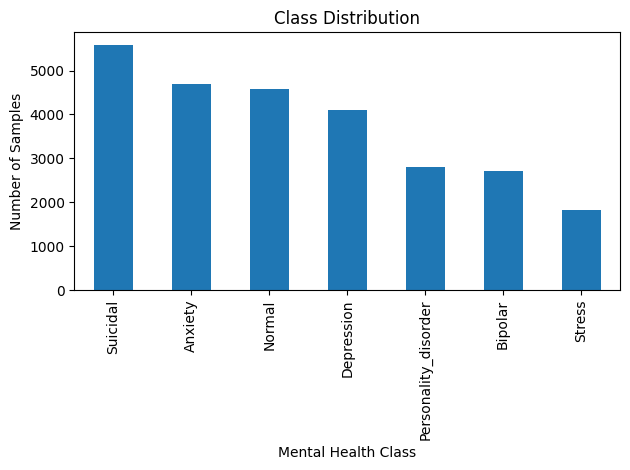

In [ ]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')

plt.xlabel('Mental Health Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df2 = pd.read_csv('/content/gdrive/MyDrive/Dissertation Files/Combined Data.csv')

df2.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df2['status'].value_counts()



,count
status,
Normal,16351
Depression,15404
Suicidal,10653
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201


In [ ]:
df2['status'] = df2['status'].replace('Personality disorder', 'Personality_disorder')

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
df2.duplicated().sum()

np.int64(0)

In [ ]:
df2.isnull().sum()

,0
Unnamed: 0,0
statement,362
status,0


In [ ]:
df2 = df2.dropna()

df2['status'].value_counts()

,count
status,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality_disorder,1077


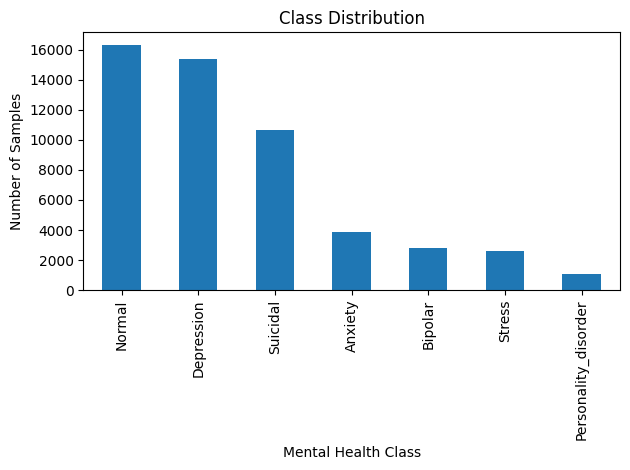

In [ ]:
df2['status'].value_counts().plot(kind='bar')

plt.xlabel('Mental Health Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##NLP

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.8 MB/s eta 0:00:00


In [ ]:
import re
import emoji
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
custom_stopwords = stop_words - {'not','no','never'}
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = emoji.demojize(text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in custom_stopwords]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)


In [ ]:
df['clean_text'] = df['statement'].apply(preprocess)

In [ ]:
df.head()

,statement,status,clean_text
0,Anyone else have symptoms much improved after ...,Bipolar,anyone else symptom much improved leaving spou...
1,"I basicaly do not exist, sure feels that way. ...",Suicidal,basicaly not exist sure feel way no friend no ...
2,Finding a sense of self It's like one minute I...,Personality_disorder,finding sense self like one minute one person ...
3,Putting into words what were just tangles in m...,Anxiety,putting word tangle brain chronic anxiety toda...
4,Anxiety makes me worry about my public image s...,Anxiety,anxiety make worry public image damn much fuck...


In [ ]:
df2['clean_text'] = df2['statement'].apply(preprocess)

In [ ]:
df2.head()

,Unnamed: 0,statement,status,clean_text
0,0,oh my gosh,Anxiety,oh gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,3,I've shifted my focus to something else but I'...,Anxiety,shifted focus something else still worried
4,4,"I'm restless and restless, it's been a month n...",Anxiety,restless restless month boy mean


##SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['status'],
    test_size=0.2,
    random_state=42,
    stratify=df['status']
)

##Word2Vec + SVM

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 41.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
from gensim.models import Word2Vec

In [ ]:
X_train_tokens = X_train.apply(lambda x: x.split())
X_test_tokens = X_test.apply(lambda x: x.split())

In [ ]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

In [ ]:
def document_vector(doc):

    words = [word for word in doc if word in w2v_model.wv]

    if len(words) == 0:
        return np.zeros(w2v_model.vector_size)

    return np.mean(w2v_model.wv[words], axis=0)


In [ ]:
X_train_w2v = np.array(
    X_train_tokens.apply(document_vector).tolist()
)

X_test_w2v = np.array(
    X_test_tokens.apply(document_vector).tolist()
)


print("X_train_w2v shape:", X_train_w2v.shape)
print("X_test_w2v shape:", X_test_w2v.shape)

X_train_w2v shape: (21066, 100)
X_test_w2v shape: (5267, 100)


In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

svm.fit(X_train_w2v, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

pred = svm.predict(X_test_w2v)
print(classification_report(y_test, pred))

                      precision    recall  f1-score   support

             Anxiety       0.78      0.75      0.77       941
             Bipolar       0.67      0.66      0.66       544
          Depression       0.58      0.38      0.46       822
              Normal       0.95      0.98      0.96       915
Personality_disorder       0.66      0.69      0.67       562
              Stress       0.58      0.71      0.64       364
            Suicidal       0.65      0.77      0.71      1119

            accuracy                           0.72      5267
           macro avg       0.70      0.70      0.69      5267
        weighted avg       0.71      0.72      0.71      5267



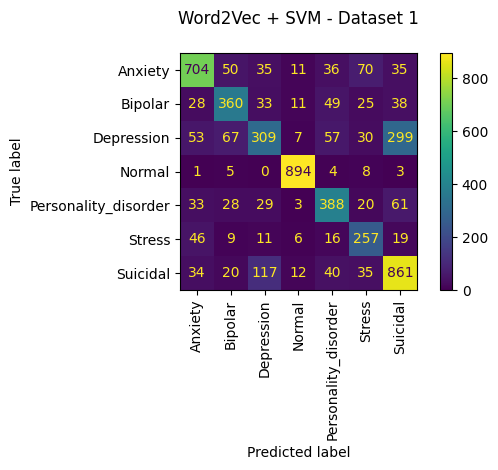

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=svm.classes_,
    xticks_rotation=90
)

plt.title('Word2Vec + SVM - Dataset 1\n')
plt.tight_layout()
plt.show()

##GENERALIZATION

In [ ]:
df2['tokens'] = df2['clean_text'].apply(lambda x: x.split())

X_w2v2 = np.array(
    df2['tokens'].apply(document_vector).tolist()
)

In [ ]:
pred2 = svm.predict(X_w2v2)

print(classification_report(df2['status'], pred2))

                      precision    recall  f1-score   support

             Anxiety       0.32      0.59      0.41      3841
             Bipolar       0.32      0.64      0.43      2777
          Depression       0.60      0.28      0.38     15404
              Normal       0.80      0.15      0.26     16343
Personality_disorder       0.10      0.42      0.16      1077
              Stress       0.16      0.42      0.23      2587
            Suicidal       0.45      0.76      0.56     10652

            accuracy                           0.39     52681
           macro avg       0.39      0.47      0.35     52681
        weighted avg       0.56      0.39      0.37     52681



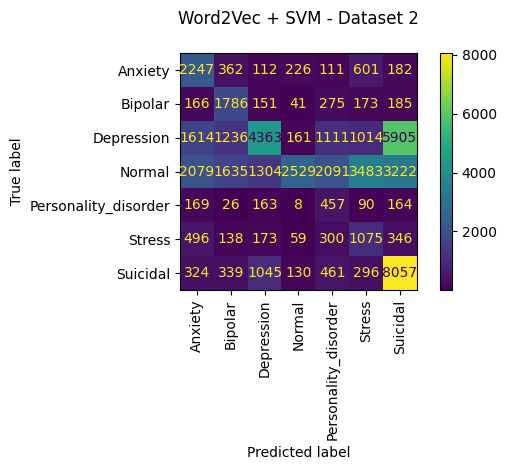

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    df2['status'],
    pred2,
    display_labels=svm.classes_,
    xticks_rotation=90
)

plt.title('Word2Vec + SVM - Dataset 2\n')
plt.tight_layout()
plt.show()

##XAI

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cf57d2aa1c1dd50bee2aa0b07350256052031eea4706929d4d95aad749f0363f
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [ ]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(
    class_names=list(svm.classes_),
    random_state=42
)

In [ ]:
def w2v_svm_predict_proba(texts, model):

    vectors = []

    for text in texts:
        tokens = preprocess(text).split()
        vector = document_vector(tokens)
        vectors.append(vector)

    vectors = np.array(vectors)

    decision_scores = model.decision_function(vectors)

    exp_scores = np.exp(
        decision_scores - np.max(decision_scores, axis=1, keepdims=True)
    )

    probabilities = exp_scores / exp_scores.sum(
        axis=1,
        keepdims=True
    )

    return probabilities

In [ ]:
import numpy as np

def explain_w2v_svm(text, model, explainer, top_n=10):

    vector = document_vector(preprocess(text).split())

    prediction = model.predict(np.array([vector]))[0]

    predicted_class_index = np.where(model.classes_ == prediction)[0][0]

    lime_explanation = explainer.explain_instance(
        text,
        lambda texts: w2v_svm_predict_proba(texts, model),
        labels=[predicted_class_index],
        num_features=top_n
    )

    return prediction, predicted_class_index, lime_explanation

###LIME1

In [ ]:
sample_index = 301

text = df['statement'].iloc[sample_index]
true_class = df['status'].iloc[sample_index]

print("Text:")
print(text)

print("\nTrue class:")
print(true_class)

Text:
Hey I’m about to kill myself and I just wanted to say the world is a very shitty place most people are just cunts it’s no wonder suicude rates are so high these days well anyways goodbye shit world may I never see u again

True class:
Suicidal


In [ ]:
prediction_w2v_svm, idx_w2v_svm, exp_w2v_svm = explain_w2v_svm(
    text,
    svm,
    explainer
)

print("Word2Vec + SVM\n")
print("Predicted:", prediction_w2v_svm)
print(exp_w2v_svm.as_list(label=idx_w2v_svm))

Word2Vec + SVM

Predicted: Suicidal
[(np.str_('kill'), 0.1332938698505556), (np.str_('world'), 0.11842458372838689), (np.str_('Hey'), -0.08884869050033142), (np.str_('high'), -0.06590655295992458), (np.str_('rates'), -0.06201812595145503), (np.str_('never'), 0.05307168190964116), (np.str_('place'), -0.05025114031742437), (np.str_('well'), -0.043173940524399074), (np.str_('wanted'), 0.030370205128979096), (np.str_('goodbye'), 0.02988609113893302)]


In [ ]:
exp_w2v_svm.show_in_notebook(
    labels=[idx_w2v_svm]
)

###LIME2

In [ ]:
sample_index = 300

text = df['statement'].iloc[sample_index]
true_class = df['status'].iloc[sample_index]

print("Text:")
print(text)

print("\nTrue class:")
print(true_class)

Text:
Married; unhappy and always listening to melodic hardcore If i was cool enough to be in a band


I wrote this

I feel like im choking;
Ive been feeling this way for days
Maybe longer, everythings become a blur
Ive had my head under water
Becoming familiar with this crushing weight.
Maybe its my depression;
Maybe its your hands holding me below.
But Either way im oddly at peace
Ive always wanted to be buried at sea
I just assumed it'd be later.
A life fully lived.
Not this meaningless existence
that ive learned to call home. 
You always said i was the lucky one;
Blessed with your love and compassion.
Who knew it'd be my faded connection to the world
My life slowly drowning
Always feeling left alone.
Never finding the answer i need
Your voice is nothing but silence 
While you scream i told you so.
But this is comfort
And this is familiar
I just wish this wasn't me.


True class:
Depression


In [ ]:
prediction_w2v_svm, idx_w2v_svm, exp_w2v_svm = explain_w2v_svm(
    text,
    svm,
    explainer
)

print("Word2Vec + SVM\n")
print("Predicted:", prediction_w2v_svm)
print(exp_w2v_svm.as_list(label=idx_w2v_svm))

Word2Vec + SVM

Predicted: Suicidal
[(np.str_('feeling'), -0.02131052941763473), (np.str_('Maybe'), 0.021076451065195845), (np.str_('always'), -0.02011068092981694), (np.str_('home'), -0.019796894934420058), (np.str_('wish'), 0.019077166615122286), (np.str_('life'), 0.01719036890970213), (np.str_('familiar'), -0.01689197192184573), (np.str_('Ive'), 0.01312188694734561), (np.str_('Never'), 0.011694401651726975), (np.str_('world'), 0.011629711064349133)]


In [ ]:
exp_w2v_svm.show_in_notebook(
    labels=[idx_w2v_svm]
)